# 16S Analyses of the Longitudinal Acne Study
## Relative Abundance Plots

Date created: 10/15/2024

Notebook authors: Yang Chen and Britta De Pessemier

Data analysis by: Tyler Myers, Britta De Pessemier, and Yang Chen

This notebook plots the following:

- 16S V1-V3 and V4 relative abundance plots at Genus taxon level aggregated by skin group
- 16S V1-V3 and V4 relative abundance plots at Genus taxon level by each sample

In [88]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_rgba


In [89]:
# Define the taxa level
taxa_level = 'Genus'

In [ ]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_22102024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')
metadata['severity_group'].value_counts()

severity_group
low Acne_L         70
moderate Acne_L    64
absent Healthy     57
absent Acne_NL     27
high Acne_L        25
low Acne_NL        23
Name: count, dtype: int64

In [91]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'V1-V3': f'../Data/16S/Tables/16S_V1-V3_{taxa_level}_collapsed.biom',
    'V4': f'../Data/16S/Tables/16S_V4_{taxa_level}_collapsed.biom'
}

In [ ]:
# Predefined color palette for specific taxon
if taxa_level == "Family":
    taxa_colors = {
        ' f__Propionibacteriaceae': '#ffa505',  # Bright orange
        ' f__Mycobacteriaceae': '#70a8dc',      # Blue
        ' f__Streptococcaceae': '#92f0f0',      # Fluorescent light blue
        ' f__Porphyromonodaceae': '#e2b46c',    # Beige
        ' f__Bacteroidaceae': '#ffe59a',        # Pastel yellow
        ' f__Neisseriaceae': '#f6475f',         # Pinkish
        ' f__Moraxellaceae': '#c5bce0',         # Pastel purplish
        ' f__Marinomonadaceae': '#f4cccd',  # Light pink
        ' f__Celerinatantimonadaceae': '#bcbcbc',  # Light gray
        ' f__Alteromonadaceae': '#daead3',  # Pale mint green
        'Others': '#ededed'                 # White
    }
elif taxa_level == "Genus":
    taxa_colors = {
        ' g__Cutibacterium': '#ffa505',  # Bright orange
        # ' g__uncultured': '#808080',      # Grey
        ' g__uncultured Neisseriaceae': '#f6475f',         # Pinkish
        ' g__Staphylococcus': '#92f0f0',      # Fluorescent light blue
        ' g__Streptococcus': '#e2b46c',    # Beige
        ' g__Corynebacterium': '#ffe59a',        # Pastel yellow
        ' g__Lawsonella': '#70a8dc',         # Light blue
        ' g__Veillonella': '#c5bce0',         # Pastel purplish
        ' g__Micrococcus':'#f4cccd',           # Pastel yellow
        ' g__Alloprevotella': '#bcbcbc',        # Light gray
        ' g__Lactobacillus': '#daead3',     # Pale mint green
        ' g__Neisseria': '#f6475f',         # Redish pink
        'Others': '#ededed'                 # White
    }

In [93]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [94]:
# Function to load BIOM table, collapse by taxa, sort rows by row sum, remove specified samples, and convert to relative abundance
def load_biom_table(biom_path, metadata_path):
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')

    # Load BIOM table and convert to a DataFrame
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Replace 'uncultured' row with 'uncultured Neisseriaceae'
    df = df.rename(index={' g__uncultured': ' g__uncultured Neisseriaceae'})
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before proceeding
    df = df.drop(columns=['row_sum'])
    
    # Convert the table to relative abundances
    df = df.div(df.sum(axis=0), axis=1)
    
    return df


In [ ]:
# Function to determine the top 15 taxon and collapse the rest as "Others"
def collapse_top_15(df):
    top_taxa = df.sum(axis=1).nlargest(15).index  # Select top 15 taxon
    df_top = df.loc[top_taxa]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_taxa)].sum()
    return df_top

In [ ]:
# Function to get or assign colors to taxon
def get_taxa_colors(taxon, global_taxa_color_map):
    for taxa in taxon:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

## Relative abundance plots

In [ ]:
def plot_relative_abundance(df, metadata, group_column, output_dir, key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()

    # Reorder the columns to Healthy, Acne Non-lesional, and Acne Lesional Low, Mod, High severity
    desired_order = ['Healthy', 'Acne_NL', 'Acne_L']

    df_grouped = df_grouped[desired_order]
    
    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg
    
    # Set plot title based on key
    if key == 'V1-V3':
        plot_title = f'16S rRNA (V1-V3) Relative Abundance'
    elif key == 'V4':
        plot_title = f'16S rRNA (V4) Relative Abundance'
    else:
        plot_title = f'16S rRNA (V4) Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(10, 10),
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=18)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=20)

    # Set x-axis labels and sample size retained after rarefaction for V1-V3 and V4
    if key == 'V1-V3':
        new_labels = ['Healthy\nSkin\n(n=47)', 'Acne\nNon-lesional\n(n=47)', 'Acne\nLesional\n(n=142)']
    elif key == 'V4':
        new_labels = ['Healthy\nSkin\n(n=27)', 'Acne\nNon-lesional\n(n=45)', 'Acne\nLesional\n(n=145)']

    # Set the new tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=18)
    plt.yticks(fontsize=18)
    
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=16, title=taxa_level, title_fontsize=18)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_27369/1648291295.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df.groupby(metadata[group_column], axis=1).mean()


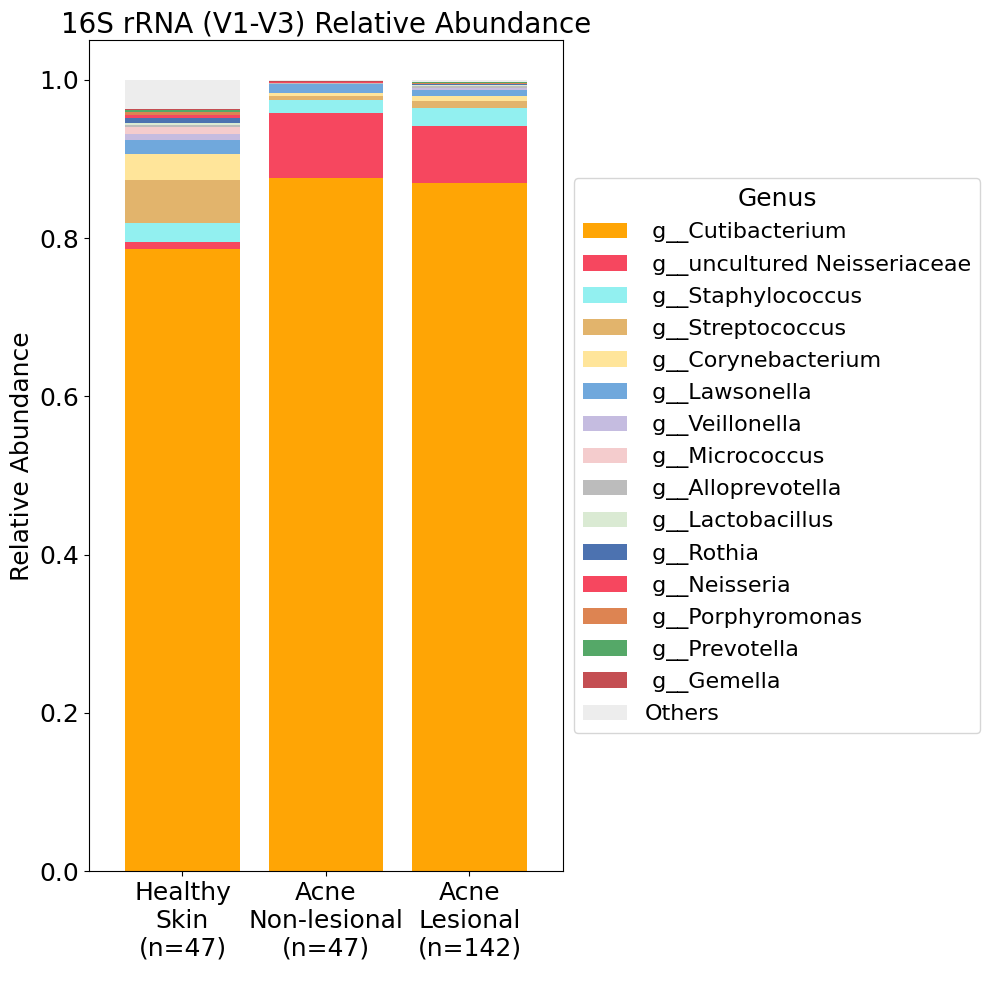

/var/folders/22/yck9vwx53w1c38tvj_c0_tz00000gn/T/ipykernel_27369/1648291295.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_grouped = df.groupby(metadata[group_column], axis=1).mean()


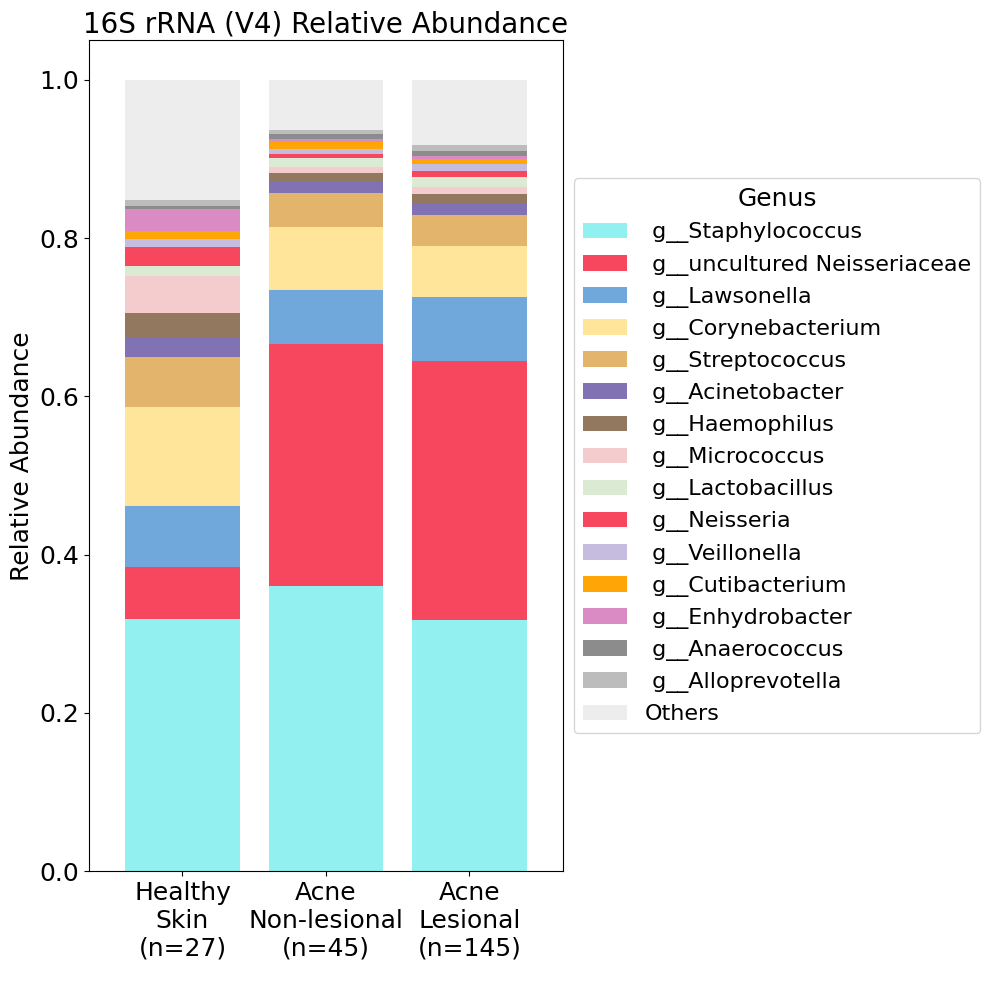

In [ ]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to taxon across both datasets
for key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path, metadata_path)
    df_top_15 = collapse_top_15(df)  # Now using the top 15 function
    
    # Define the output directory for the current key
    output_dir = '../Figures/16S_Figures/relative_abundance/'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top taxon in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_15.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_15, metadata_subset, 'group', output_dir, key, global_taxa_color_map)